In [4]:
#Clear Sky Comparison

import srfm
import srfm.main
import inspect
import importlib.metadata
import numpy as np
import matplotlib.pyplot as plt
"""If running the SRFM with a driver table, run this code."""
from srfm import *
import xarray as xr

from scipy.interpolate import interp1d

import os

from scipy.signal import convolve
import pandas as pd
from prettytable import PrettyTable as pt
from scipy import constants as const
import iris
import iris.quickplot as qplt
import json

from scipy.constants import h, c, k


/home/m/moulin-garrigues/miniforge3/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


## Generating Clear Sky Radiances SRFM

In [13]:

#Load Data - Channels_3
srf_file_7_ = np.loadtxt(
    "/home/m/moulin-garrigues/rtcoef_msg_3_seviri_srf_ch07.txt",
    skiprows=4)
#Channel file9
srf_file_9_= np.loadtxt(
    "/home/m/moulin-garrigues/rtcoef_msg_3_seviri_srf_ch09.txt",
    skiprows=4)
#Channel file10
srf_file_10_ = np.loadtxt(
    "/home/m/moulin-garrigues/rtcoef_msg_3_seviri_srf_ch10.txt",
    skiprows=4)
#Channel file11
srf_file_11_= np.loadtxt(
    "/home/m/moulin-garrigues/rtcoef_msg_3_seviri_srf_ch11.txt",
    skiprows=4)


## Without get wav

In [173]:
#AVG RADIANCE FOR EACH CHANNEL 

def channel_radiance_multi(spec_a, spec_b, srf_files_a, srf_files_b, spec_name, output_file):

    def integrate_channel_(spec, srf_file):

        wv = spec.wavenumber.values
        spc = spec.values

        ils_x = srf_file[:, 0]
        ils_y = srf_file[:, 1]

        srf = interp1d(
            ils_x,
            ils_y,
            bounds_error=False,
            fill_value=0.0
        )(wv)

        plot = spc * srf
        
        rad = np.trapezoid(plot, wv) / np.trapezoid(srf, wv)

        return rad, plot

    radiances = []
    plots = []

    for srf_file in srf_files_a:
        rad, plot = integrate_channel_(spec_a, srf_file)
        radiances.append(rad)
        plots.append(plot)

    for srf_file in srf_files_b:
        rad, plot = integrate_channel_(spec_b, srf_file)
        radiances.append(rad)
        plots.append(plot)

    rad_ch07, rad_ch09, rad_ch10, rad_ch11 = radiances
    print(radiances)
    return radiances, plots

## New function with getwav + file with SRFM new btemp 

In [1]:
def get_wavenumber(spec):
    """
    Return physical wavenumber grid from an xarray DataArray.
    Handles files with wavenumber as coordinate or only as a dimension.
    """

    params = json.loads(spec.attrs["srfm_params"])

    wv_min = params["spc_wvnmlo"]
    res = params["spc_res"]

    return wv_min + res * np.arange(spec.sizes["wavenumber"])



def channel_radiance_multi(spec_a, spec_b, srf_files_a, srf_files_b, spec_name=None, output_file=None):

    def integrate_channel_(spec, srf_file):

        wv = get_wavenumber(spec)
        spc = spec.values

        ils_x = srf_file[:, 0]
        ils_y = srf_file[:, 1]

        srf = interp1d(
            ils_x,
            ils_y,
            bounds_error=False,
            fill_value=0.0
        )(wv)

        weighted_rad = spc * srf

        rad = (
            np.trapezoid(weighted_rad, wv)
            / np.trapezoid(srf, wv)
        )

        return rad, weighted_rad


    radiances = []
    plots = []

    # Band a channels
    for srf_file in srf_files_a:
        rad, plot = integrate_channel_(spec_a, srf_file)
        radiances.append(rad)
        plots.append(plot)

    # Band b channels
    for srf_file in srf_files_b:
        rad, plot = integrate_channel_(spec_b, srf_file)
        radiances.append(rad)
        plots.append(plot)


    print("Channel radiances:", radiances)

    return radiances, plots

In [ ]:
def get_wavenumber(spec):
    """
    Return physical wavenumber grid from an xarray DataArray.
    Handles files with wavenumber as coordinate or only as a dimension.
    """

    params = json.loads(spec.attrs["srfm_params"])

    wv_min = params["spc_wvnmlo"]
    res = params["spc_res"]

    return wv_min + res * np.arange(spec.sizes["wavenumber"])



def channel_radiance_multi(spec_a, spec_b, srf_files_a, srf_files_b, spec_name=None, output_file=None):

    def integrate_channel_(spec, srf_file):

        wv = get_wavenumber(spec)
        spc = spec.values

        ils_x = srf_file[:, 0]
        ils_y = srf_file[:, 1]

        srf = interp1d(
            ils_x,
            ils_y,
            bounds_error=False,
            fill_value=0.0
        )(wv)

        weighted_rad = spc * srf

        rad = (
            np.trapezoid(weighted_rad, wv)
            / np.trapezoid(srf, wv)
        )

        return rad, weighted_rad


    radiances = []
    plots = []

    # Band a channels
    for srf_file in srf_files_a:
        rad, plot = integrate_channel_(spec_a, srf_file)
        radiances.append(rad)
        plots.append(plot)

    # Band b channels
    for srf_file in srf_files_b:
        rad, plot = integrate_channel_(spec_b, srf_file)
        radiances.append(rad)
        plots.append(plot)


    print("Channel radiances:", radiances)

    return radiances, plots

In [14]:
##With new Btemp
prof = "0"
path = "/network/group/aopp/eodg/RGG008_GRAINGER_IASIVOLC/knizek/MetOffice_clear_sky_btemp/results/"

spec = "123456789"
ds_a = xr.open_dataset(f"{path}/{prof}/results_{prof}_{spec}/rad_{prof}_{spec}a.nc")
ds_b = xr.open_dataset(f"{path}/{prof}/results_{prof}_{spec}/rad_{prof}_{spec}b.nc")


srf_files_a = [srf_file_7_]
srf_files_b = [srf_file_9_, srf_file_10_, srf_file_11_]



output_file = f'/home/m/moulin-garrigues/SRFM_RTTOV/Mes_resultats/Clear_Sky_SRFM_btemp/Clear_{prof}_MSG3_btemp_wav.txt'

rad_a = ds_a["rad"]
rad_b = ds_b["rad"]

radiances, _ = channel_radiance_multi(
    rad_a,
    rad_b,
    srf_files_a,
    srf_files_b,
    spec,
    output_file
)

rad_ch07, rad_ch09, rad_ch10, rad_ch11 = radiances

print(f"Channel 07: {rad_ch07:.6f}")
print(f"Channel 09: {rad_ch09:.6f}")
print(f"Channel 10: {rad_ch10:.6f}")
print(f"Channel 11: {rad_ch11:.6f}")

rad_ch07, rad_ch09, rad_ch10, rad_ch11 = radiances

width = 27
with open(output_file, "w") as f:
    # Header
    f.write(
        f"{'ID':<15}"
        f"{'Channel 11 (13.4 µm)':>{width}}"
        f"{'Channel 10 (12 µm)':>{width}}"
        f"{'Channel 09 (10.8 µm)':>{width}}"
        f"{'Channel 07 (8.7 µm)':>{width}}\n"
    )

    f.write("-" * (15 + 4 * width) + "\n")

    # Single spectrum
    f.write(
        f"{spec:<15}"
        f"{rad_ch11:>{width}.6f}"
        f"{rad_ch10:>{width}.6f}"
        f"{rad_ch09:>{width}.6f}"
        f"{rad_ch07:>{width}.6f}\n"
    )

Channel radiances: [np.float64(0.05928753935379773), np.float64(0.10425686169574942), np.float64(0.11829961032027535), np.float64(0.08028995241197583)]
Channel 07: 0.059288
Channel 09: 0.104257
Channel 10: 0.118300
Channel 11: 0.080290


## Generating Clear Sky Brightness Temp SRFM

In [9]:

#Load Data - Channels_3
srf_file_7_ = np.loadtxt(
    "/home/m/moulin-garrigues/rtcoef_msg_3_seviri_srf_ch07.txt",
    skiprows=4)
#Channel file9
srf_file_9_= np.loadtxt(
    "/home/m/moulin-garrigues/rtcoef_msg_3_seviri_srf_ch09.txt",
    skiprows=4)
#Channel file10
srf_file_10_ = np.loadtxt(
    "/home/m/moulin-garrigues/rtcoef_msg_3_seviri_srf_ch10.txt",
    skiprows=4)
#Channel file11
srf_file_11_= np.loadtxt(
    "/home/m/moulin-garrigues/rtcoef_msg_3_seviri_srf_ch11.txt",
    skiprows=4)


In [166]:
h= const.h
c = const.c 
k =const.k         # 1.380649e-23# Speed of light (m/s)
def radiance_wn_cm_(T, wn):
    """
    Planck radiance for:
      T  : temperature (K)
      wn : wavenumber (cm^-1)

       Returns:
        mW m-2 sr-1 (cm-1)-1
    """
    wn_m = wn * 100.0

    # Planck radiance per metre wavenumber
    B_m = (
        2 * h * c**2 * wn_m**3 /
        (np.exp((h * c * wn_m) / (k * T)) - 1)
    )

    # Convert:
    # W m^-2 sr^-1 m^-1 -> mW m^-2 sr^-1 (cm^-1)^-1
    B_cm = B_m *10**5

    return B_cm
radiance_wn_cm_(289, 0.9270688810E+03)

np.float64(94.87437748177233)

In [22]:
#Brightness Temp
h= const.h
c = const.c 
k =const.k 

def BT(rad, wn):
    """
    Brightness temperature.

    rad : W m^-2 sr^-1 (cm^-1)^-1
    wn  : wavenumber (cm^-1)

    Returns:
        K
    """
    wn_m = wn * 100.0

    # Convert radiance from per cm^-1 to per m^-1
    B_m = rad / 100.0

    # Planck law expressed per unit wavenumber
    T = (
        const.h * const.c * wn_m / const.k
        / np.log(1.0 + (2.0 * const.h * const.c**2 * wn_m**3) / B_m)
    )

    return T

print(BT(0.09487437748177233, 0.9270688810E+03))
BT(0.059213,0.1147372612e+04 )

289.0


np.float64(288.6168970495727)

In [45]:
prof = "0"
path = "/network/group/aopp/eodg/RGG008_GRAINGER_IASIVOLC/knizek/MetOffice_clear_sky_btemp/results/"

spec = "123456789"
ds_a = xr.open_dataset(f"{path}/{prof}/results_{prof}_{spec}/rad_{prof}_{spec}a.nc")
ds_b = xr.open_dataset(f"{path}/{prof}/results_{prof}_{spec}/rad_{prof}_{spec}b.nc")


srf_files_a = [srf_file_7_]
srf_files_b = [srf_file_9_, srf_file_10_, srf_file_11_]



output_file = f'/home/m/moulin-garrigues/SRFM_RTTOV/Mes_resultats/Clear_Convert_BT/BT_Clear_{prof}_MSG3_btemp_wav.txt'

rad_a = ds_a["rad"]
rad_b = ds_b["rad"]

radiances, _ = channel_radiance_multi(
    rad_a,
    rad_b,
    srf_files_a,
    srf_files_b,
    spec,
    output_file
)

rad_ch07, rad_ch09, rad_ch10, rad_ch11 = radiances

print(f"Channel 07: {rad_ch07:.6f}")
print(f"Channel 09: {rad_ch09:.6f}")
print(f"Channel 10: {rad_ch10:.6f}")
print(f"Channel 11: {rad_ch11:.6f}")

# Channel constants from RTTOV
channel_params = {
    7: {"nu": 0.1147372612e+04},
    9: {"nu": 0.9270688810e+03},
    10: {"nu": 0.8368734588e+03},
    11: {"nu": 0.7481686747e+03}}

channel_radiances = {
    7: rad_ch07,
    9: rad_ch09,
    10: rad_ch10,
    11: rad_ch11,
}

BT_channels = {}

for channel, rad in channel_radiances.items():
    nu = channel_params[channel]["nu"]
    BT_channels[channel] = BT(rad, nu)

BT_ch07 = BT(rad_ch07, channel_params[7]["nu"])
BT_ch09 = BT(rad_ch09, channel_params[9]["nu"])
BT_ch10 = BT(rad_ch10, channel_params[10]["nu"])
BT_ch11 = BT(rad_ch11, channel_params[11]["nu"])

print(f"Channel 07: {rad_ch07:.6f}  ->  {BT_ch07:.3f} K")
print(f"Channel 09: {rad_ch09:.6f}  ->  {BT_ch09:.3f} K")
print(f"Channel 10: {rad_ch10:.6f}  ->  {BT_ch10:.3f} K")
print(f"Channel 11: {rad_ch11:.6f}  ->  {BT_ch11:.3f} K")



width = 27
with open(output_file, "w") as f:

    f.write(
        f"{'ID':<15}"
        f"{'Ch 11 BT':>{width}}"
        f"{'Ch 10 BT':>{width}}"
        f"{'Ch 09 BT':>{width}}"
        f"{'Ch 07 BT':>{width}}\n"
    )

    f.write("-" * (15 + 4 * width) + "\n")

    f.write(
        f"{spec:<15}"
        f"{BT_ch11:>{width}.3f}"
        f"{BT_ch10:>{width}.3f}"
        f"{BT_ch09:>{width}.3f}"
        f"{BT_ch07:>{width}.3f}\n"
    )

Channel radiances: [np.float64(0.05928753935379773), np.float64(0.10425686169574942), np.float64(0.11829961032027535), np.float64(0.08028995241197583)]
Channel 07: 0.059288
Channel 09: 0.104257
Channel 10: 0.118300
Channel 11: 0.080290
Channel 07: 0.059288  ->  288.680 K
Channel 09: 0.104257  ->  294.964 K
Channel 10: 0.118300  ->  294.071 K
Channel 11: 0.080290  ->  259.691 K


In [132]:
path = "/network/group/aopp/eodg/RGG008_GRAINGER_IASIVOLC/knizek/MetOffice_clear_sky/results/"
prof = "1"
spec = "123456789"
ds_a = xr.open_dataset(f"{path}/{prof}/results_{prof}_{spec}/rad_{prof}_{spec}a.nc")

#print(ds_a.srfm_param)
print(ds_a.data_vars)
# or
print(list(ds_a.variables))
print(ds_a.variables)

Data variables:
    rad      (wavenumber) float64 847kB ...
['rad']
Frozen({'rad': <xarray.Variable (wavenumber: 105900)> Size: 847kB
[105900 values with dtype=float64]
Attributes:
    units:        W m-2 sr-1 cm
    long_name:    Radiance
    srfm_params:  {"base_plots": false, "out_mode": "netcdf", "show_plots": f...})


## Reading RTTOV Clear Sky radiance

### Clear Sky Radiances - 0.5_70_312.53 _Level70

### Clear Sky Radiances - 7.0_70_312.53 _Level70 - CHECK IF SAME

In [65]:
file= "combined_file_50.0_70_312.53_1_nobias"

cubes_02 = iris.load(f"/home/m/moulin-garrigues/RTTOV/Full_data_3_08/{file}.nc")
print(cubes_02)


0: Ch 10 simulated brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
1: Ch 10 clear sky brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
2: Ch 07 clear sky radiance / (mW/m^2/sr/cm^-1) (time: 1; latitude: 13; longitude: 43)
3: Ch 09 simulated brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
4: Ch 07 simulated brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
5: Ch 09 clear sky radiance / (mW/m^2/sr/cm^-1) (time: 1; latitude: 13; longitude: 43)
6: Ch 11 clear sky brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
7: Ch 10 clear sky radiance / (mW/m^2/sr/cm^-1) (time: 1; latitude: 13; longitude: 43)
8: Ch 11 clear sky radiance / (mW/m^2/sr/cm^-1) (time: 1; latitude: 13; longitude: 43)
9: Ch 11 simulated brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
10: Ch 07 clear sky brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
11: Ch 09 clear sky brightness temps / (K) (time: 1; latitude: 13; longitude: 43)


In [66]:
clear_rad_7= cubes_02[2].data
info_clear_rad_7 = cubes_02[2]
print(info_clear_rad_7)
print(clear_rad_7)

clear_rad_9= cubes_02[5].data
info_clear_rad_9 = cubes_02[5]
print(info_clear_rad_9)
print(clear_rad_9)

clear_rad_10= cubes_02[7].data
info_clear_rad_10 = cubes_02[7]
print(info_clear_rad_10)
print(clear_rad_10)

clear_rad_11= cubes_02[8].data
info_clear_rad_11 = cubes_02[8]
print(info_clear_rad_11)
print(clear_rad_11)

Ch 07 clear sky radiance / (mW/m^2/sr/cm^-1) (time: 1; latitude: 13; longitude: 43)
    Dimension coordinates:
        time                                      x            -              -
        latitude                                  -            x              -
        longitude                                 -            -              x
    Attributes:
        Conventions                          'CF-1.7'
[[[60.66609  61.696022 57.744892 50.420002 60.118435 60.95606  23.495121
   23.5881   54.505684 22.663275 25.392834 57.4097   60.140476 61.171604
   54.835197 61.990982 41.774097 25.74284  57.084694 49.376335 56.805576
   61.73556  57.352604 56.4475   59.144264 50.89418  51.897182 62.249184
   55.08959  24.544443 59.89491  60.610184 59.23136  37.968582 63.19365
   51.374935 61.96261  62.90535  63.558964 59.08315  60.007572 58.403778
   54.59496 ]
  [57.51918  58.680893 26.659805 59.31802  60.788784 57.630226 56.003986
   58.4728   45.996998 62.58042  66.65543  27.375486 62

In [67]:
#Inputing Clear Sky Radiances into csv file

input_file = f"/home/m/moulin-garrigues/RTTOV/Full_data_3_08/{file}.nc"
cubes_02 = iris.load(input_file)
info_sim_bt_7 = cubes_02[2]

info_sim_bt_9 = cubes_02[5]

info_sim_bt_10 = cubes_02[7]

info_sim_bt_11 = cubes_02[8]


# Extract cubes
Radiance_channels = {
    7: cubes_01[2].data,
    9: cubes_01[5].data,
    10: cubes_01[7].data,
    11: cubes_01[8].data,
}

# Coordinates
lat = cubes_02[10].coord('latitude').points
lon = cubes_02[10].coord('longitude').points

# Take time = 0
lon2d, lat2d = np.meshgrid(lon, lat)

# Start dataframe with coordinates
df = pd.DataFrame({
    "latitude": lat2d.ravel(),
    "longitude": lon2d.ravel()
})


for ch in [7, 9, 10, 11]:
    df[f"Radiance_{ch}"] = Radiance_channels[ch].ravel()
    
# Save
df.to_csv(
    f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/ClearRad_{file}.csv",
    index=False
)
with open(f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/ClearInfo_{file}.txt", "w") as f:
    f.write(f"Channel 7\n{cubes_01[2]}\n\n")
    f.write(f"Channel 9\n{cubes_01[5]}\n\n")
    f.write(f"Channel 10\n{cubes_01[7]}\n\n")
    f.write(f"Channel 11\n{cubes_01[8]}\n")
print(df.head())
print(df.shape)

    latitude  longitude  Radiance_7  Radiance_9  Radiance_10  Radiance_11
0  50.078125 -29.882812   60.666088   99.189041   111.255112    86.005524
1  50.078125 -29.648438   61.696022  100.886040   114.943611    90.088936
2  50.078125 -29.414062   57.744892   96.373894   109.277496    84.058083
3  50.078125 -29.179688   50.420002   86.155602    98.761017    79.485252
4  50.078125 -28.945312   60.118435   98.572617   110.484856    86.941521
(559, 6)


### Clear Sky BT - 7.0_70_312.53 _Level70 - CHECK IF SAME

In [52]:
file= "combined_file_50.0_70_312.53_1_nobias"

cubes_02 = iris.load(f"/home/m/moulin-garrigues/RTTOV/Full_data_3_08/{file}.nc")
print(cubes_02)


0: Ch 10 clear sky radiance / (mW/m^2/sr/cm^-1) (time: 1; latitude: 13; longitude: 43)
1: Ch 07 clear sky radiance / (mW/m^2/sr/cm^-1) (time: 1; latitude: 13; longitude: 43)
2: Ch 09 clear sky brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
3: Ch 09 clear sky radiance / (mW/m^2/sr/cm^-1) (time: 1; latitude: 13; longitude: 43)
4: Ch 11 clear sky brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
5: Ch 07 simulated brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
6: Ch 11 clear sky radiance / (mW/m^2/sr/cm^-1) (time: 1; latitude: 13; longitude: 43)
7: Ch 11 simulated brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
8: Ch 10 simulated brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
9: Ch 07 clear sky brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
10: Ch 09 simulated brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
11: Ch 10 clear sky brightness temps / (K) (time: 1; latitude: 13; longitude: 43)


In [53]:
clear_BT_7= cubes_02[9].data
info_clear_BT_7 = cubes_02[9]
print(info_clear_BT_7)
print(clear_BT_7)

clear_BT_9= cubes_02[2].data
info_clear_BT_9 = cubes_02[2]
print(info_clear_BT_9)
print(clear_BT_9)

clear_BT_10= cubes_02[11].data
info_clear_BT_10 = cubes_02[11]
print(info_clear_BT_10)
print(clear_BT_10)

clear_BT_11= cubes_02[4].data
info_clear_BT_11 = cubes_02[4]
print(info_clear_BT_11)
print(clear_BT_11)

Ch 07 clear sky brightness temps / (K) (time: 1; latitude: 13; longitude: 43)
    Dimension coordinates:
        time                                x            -              -
        latitude                            -            x              -
        longitude                           -            -              x
    Attributes:
        Conventions                    'CF-1.7'
[[[289.88367 290.7404  287.4009  280.78873 289.42426 290.12582 248.56203
   248.70975 284.54947 247.22162 251.5001  287.1108  289.4428  290.30533
   284.84457 290.98398 272.10318 252.02509 286.82843 279.7959  286.5851
   290.77307 287.06128 286.27176 288.60028 281.23532 282.17093 291.19666
   285.07156 250.20624 289.236   289.8369  288.67432 267.89398 291.96957
   281.6853  290.96054 291.73444 292.26654 288.54828 289.33093 287.96796
   284.62955]
  [287.2057  288.2052  253.37735 288.74792 289.98624 287.30176 285.8819
   288.02713 276.4819  291.46857 294.74014 254.41043 291.2435  289.29898
   290.31885 

In [56]:
#Inputing Clear Sky Radiances into csv file

input_file = f"/home/m/moulin-garrigues/RTTOV/Full_data_3_08/{file}.nc"
cubes_02 = iris.load(input_file)
clear_BT_7= cubes_02[9].data
clear_BT_9= cubes_02[2].data
clear_BT_10= cubes_02[11].data
clear_BT_11= cubes_02[4].data

# Extract cubes
BT_channels = {
    7: cubes_02[9].data,
    9: cubes_02[2].data,
    10: cubes_02[11].data,
    11: cubes_02[4].data,
}

# Coordinates
lat = cubes_02[10].coord('latitude').points
lon = cubes_02[10].coord('longitude').points

# Take time = 0
lon2d, lat2d = np.meshgrid(lon, lat)

# Start dataframe with coordinates
df = pd.DataFrame({
    "latitude": lat2d.ravel(),
    "longitude": lon2d.ravel()
})


for ch in [7, 9, 10, 11]:
    df[f"BT_{ch}"] = BT_channels[ch].ravel()
    
# Save
df.to_csv(
    f"/home/m/moulin-garrigues/RTTOV/Full_Rad_7_08/ClearBT_{file}.csv",
    index=False
)
with open(f"/home/m/moulin-garrigues/RTTOV/Full_Rad_7_08/ClearInfoBT_{file}.txt", "w") as f:
    f.write(f"Channel 7\n{cubes_02[9]}\n\n")
    f.write(f"Channel 9\n{cubes_02[2]}\n\n")
    f.write(f"Channel 10\n{cubes_02[11]}\n\n")
    f.write(f"Channel 11\n{cubes_02[4]}\n")
print(df.head())
print(df.shape)

    latitude  longitude        BT_7        BT_9       BT_10       BT_11
0  50.078125 -29.882812  289.883667  291.974701  289.931824  264.180969
1  50.078125 -29.648438  290.740387  293.051422  292.189240  267.166931
2  50.078125 -29.414062  287.400909  290.164856  288.704865  262.730225
3  50.078125 -29.179688  280.788727  283.323639  281.966553  259.251038
4  50.078125 -28.945312  289.424255  291.580994  289.455383  264.871948
(559, 6)


## Merging SRFM&RTTOV

### Merge the files using this:

### Profile0

### Profile N - Loop over Profiles

In [15]:

fileID = "ClearRad_combined_file_0.5_70_312.53_1_nobias" #RTTOV Clear Sky file ID -Assume clear sky is the same for each ash combo file for given pixel

rttov = pd.read_csv(
    f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Clear/{fileID}.csv" #RTTOV Clear Sky file 
)

profile_locations = {
    "0": (50.078125, -29.882812),
    "1": (50.078125, -29.648438),
    "2": (50.078125, -29.414062),
    "3": (50.078125,-29.179688),
    "4": (50.078125,-28.945312 ),
    "5": (50.078125, -28.710938),
    "6": (50.078125, -28.476562),
    "7": (50.078125, -28.242188),
    "8": (50.078125,-28.007812 ),
    "9": (50.078125, -27.773438)
}


for profile, (target_lat, target_lon) in profile_locations.items():

    # Read SRFM file for this profile
    srfm = pd.read_csv(
        f"/home/m/moulin-garrigues/SRFM_RTTOV/Mes_resultats/Clear_Sky_SRFM_btemp/Clear_{profile}_MSG3_btemp_wav.txt",
        sep=r"\s+",
        skiprows=2,
        names=["ID", "SRFM_Ch11", "SRFM_Ch10", "SRFM_Ch09", "SRFM_Ch07"]
    )

    # Add metadata
    srfm["profile"] = profile
    srfm["case"] = "clear_sky"
    srfm["latitude_target"] = target_lat
    srfm["longitude_target"] = target_lon

    # Find matching RTTOV pixel
    rttov_pixel = rttov[
        np.isclose(rttov["latitude"], target_lat) &
        np.isclose(rttov["longitude"], target_lon)
    ].iloc[0]

    # Add RTTOV radiances
    srfm["RTTOV_Ch07"] = rttov_pixel["Radiance_7"]
    srfm["RTTOV_Ch09"] = rttov_pixel["Radiance_9"]
    srfm["RTTOV_Ch10"] = rttov_pixel["Radiance_10"]
    srfm["RTTOV_Ch11"] = rttov_pixel["Radiance_11"]

    srfm["RTTOV_latitude"] = rttov_pixel["latitude"]
    srfm["RTTOV_longitude"] = rttov_pixel["longitude"]

    # Save one merged file per profile
    srfm.to_csv(
        f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_btemp_WAV/ClearSkybtemp_Merge_{profile}_wav.csv",
        index=False
    )

    print(f"Finished profile {profile}")

Finished profile 0
Finished profile 1
Finished profile 2
Finished profile 3
Finished profile 4
Finished profile 5
Finished profile 6
Finished profile 7
Finished profile 8
Finished profile 9


#### Merging for SRFM BT

In [70]:

fileID = "ClearBT_combined_file_50.0_70_312.53_1_nobias" #RTTOV Clear Sky file ID -Assume clear sky is the same for each ash combo file for given pixel
rttov = pd.read_csv(
    f"/home/m/moulin-garrigues/RTTOV/Full_Rad_7_08/{fileID}.csv" #RTTOV Clear Sky file 
)

profile_locations = {
    "0": (50.078125, -29.882812),
    "1": (50.078125, -29.648438),
    "2": (50.078125, -29.414062),
    "3": (50.078125,-29.179688),
    "4": (50.078125,-28.945312 ),
    "5": (50.078125, -28.710938),
    "6": (50.078125, -28.476562),
    "7": (50.078125, -28.242188),
    "8": (50.078125,-28.007812 ),
    "9": (50.078125, -27.773438)
}


for profile, (target_lat, target_lon) in profile_locations.items():

    # Read SRFM file for this profile
    srfm = pd.read_csv(
        f"/home/m/moulin-garrigues/SRFM_RTTOV/Mes_resultats/Clear_Convert_BT/BT_Clear_{profile}_MSG3_btemp_wav.txt",
        sep=r"\s+",
        skiprows=2,
        names=["ID", "SRFM_Ch11", "SRFM_Ch10", "SRFM_Ch09", "SRFM_Ch07"]
    )

    # Add metadata
    srfm["profile"] = profile
    srfm["case"] = "clear_sky"
    srfm["latitude_target"] = target_lat
    srfm["longitude_target"] = target_lon

    # Find matching RTTOV pixel
    rttov_pixel = rttov[
        np.isclose(rttov["latitude"], target_lat) &
        np.isclose(rttov["longitude"], target_lon)
    ].iloc[0]

    # Add RTTOV radiances
    srfm["RTTOV_Ch07"] = rttov_pixel["BT_7"]
    srfm["RTTOV_Ch09"] = rttov_pixel["BT_9"]
    srfm["RTTOV_Ch10"] = rttov_pixel["BT_10"]
    srfm["RTTOV_Ch11"] = rttov_pixel["BT_11"]

    srfm["RTTOV_latitude"] = rttov_pixel["latitude"]
    srfm["RTTOV_longitude"] = rttov_pixel["longitude"]

    # Save one merged file per profile
    srfm.to_csv(
        f"/home/m/moulin-garrigues/RTTOV/Full_Rad_7_08/Merge_btemp_WAV_clear/ClearSkybtemp_Merge_{profile}_wav_BT.csv",
        index=False
    )

    print(f"Finished profile {profile}")

Finished profile 0
Finished profile 1
Finished profile 2
Finished profile 3
Finished profile 4
Finished profile 5
Finished profile 6
Finished profile 7
Finished profile 8
Finished profile 9


In [63]:
print(rttov.columns.tolist())

['latitude', 'longitude', 'BT_7', 'BT_9', 'BT_10', 'BT_11']


# Compare Clear Sky Data - btemp srfm files - BRIGHTNESS TEMPERATURE

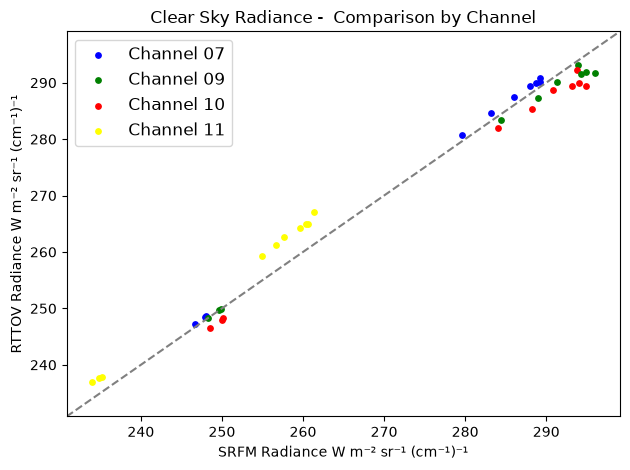

Statistics
----------------------------------------
Channel 07
  Mean Bias = -1.083365
  RMSE      = 1.131854
Channel 09
  Mean Bias = 1.488930
  RMSE      = 2.015187
Channel 10
  Mean Bias = 2.781014
  RMSE      = 3.023797
Channel 11
  Mean Bias = -4.149326
  RMSE      = 4.263131


In [71]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "yellow"
}

# Store all differences for each channel
all_diff = {ch: [] for ch in channels}

for profile in range(10):

    ClearSkyDatabtemp_BT = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_7_08/Merge_btemp_WAV_clear/ClearSkybtemp_Merge_{profile}_wav_BT.csv"

    df = pd.read_csv(ClearSkyDatabtemp_BT)

    for ch in channels:

        srfm = df[f"SRFM_Ch{ch:02d}"]
        rttov = df[f"RTTOV_Ch{ch:02d}"] 
        ax.scatter(
            srfm,
            rttov,
            color = colors[ch],
            s=15,
            label=f"Channel {ch:02d}" if profile == 0 else None,
            
        )
         # Save differences for statistics
        all_diff[ch].extend((srfm - rttov).values)
#x=y
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, color="gray", linestyle="--")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("SRFM Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_ylabel("RTTOV Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_title("Clear Sky Radiance -  Comparison by Channel")
ax.legend(fontsize=12)



plt.tight_layout()
plt.show()

print("Statistics")
print("-" * 40)
for ch in channels:
    diff = np.array(all_diff[ch])
    mean_bias = diff.mean()
    rmse = np.sqrt(np.mean(diff**2))

    print(f"Channel {ch:02d}")
    print(f"  Mean Bias = {mean_bias:.6f}")
    print(f"  RMSE      = {rmse:.6f}")


# Compare Clear Sky Data - btemp srfm files - RADIANCE

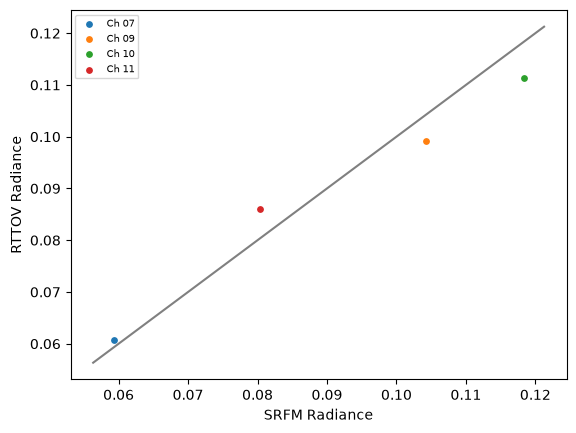

In [34]:
profile = 0
ClearSkyData_btemp = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_btemp_WAV/ClearSkybtemp_Merge_{profile}_wav.csv"


df = pd.read_csv(ClearSkyData_btemp)

# Extract specific columns
clear_s = ["SRFM_Ch07", "SRFM_Ch09","SRFM_Ch10","SRFM_Ch11"] 
clear_r = ["RTTOV_Ch07", "RTTOV_Ch09","RTTOV_Ch10","RTTOV_Ch11"] 
res_s = df[clear_s]
res_r = df[clear_r]
res_W=res_r*10**-3


clear_s = ["SRFM_Ch07", "SRFM_Ch09","SRFM_Ch10","SRFM_Ch11"] 
clear_r = ["RTTOV_Ch07", "RTTOV_Ch09","RTTOV_Ch10","RTTOV_Ch11"] 
res_s = df[clear_s]
res_r = df[clear_r]
res_W=res_r*10**-3


fig, ax = plt.subplots()
channels = [7, 9, 10, 11]

for ch in channels:
    ax.scatter(
        df[f"SRFM_Ch{ch:02d}"],
        df[f"RTTOV_Ch{ch:02d}"] * 1e-3,
        label=f"Ch {ch:02d}",
        s = 15
    )
lims = ax.get_xlim()
ax.plot(lims, lims, color = "gray")
ax.set_xlabel("SRFM Radiance")
ax.set_ylabel("RTTOV Radiance")
ax.legend(fontsize = 7)




FileNotFoundError: [Errno 2] No such file or directory: '/home/m/moulin-garrigues/SRFM_RTTOV/Mes_resultats/Clear_Sky_SRFM_btemp/ClearSkybtemp_Merge_0_wav.csv'

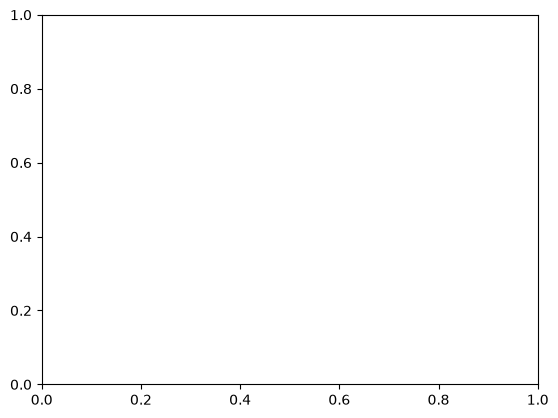

In [14]:

fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "yellow"
}

# Store all differences for each channel
all_diff = {ch: [] for ch in channels}

for profile in range(10):

    ClearSkyDatabtemp = f"/home/m/moulin-garrigues/SRFM_RTTOV/Mes_resultats/Clear_Sky_SRFM_btemp/Clearbtemp_Merge_{profile}_wav.csv"

    df = pd.read_csv(ClearSkyDatabtemp)

    for ch in channels:

        srfm = df[f"SRFM_Ch{ch:02d}"]
        rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3
        ax.scatter(
            srfm,
            rttov,
            color = colors[ch],
            s=15,
            label=f"Channel {ch:02d}" if profile == 0 else None,
            
        )
         # Save differences for statistics
        all_diff[ch].extend((srfm - rttov).values)
#x=y
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, color="gray", linestyle="--")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("SRFM Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_ylabel("RTTOV Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_title("Clear Sky Radiance -  Comparison by Channel")
ax.legend(fontsize=12)



plt.tight_layout()
plt.show()

print("Statistics")
print("-" * 40)
for ch in channels:
    diff = np.array(all_diff[ch])
    mean_bias = diff.mean()
    rmse = np.sqrt(np.mean(diff**2))

    print(f"Channel {ch:02d}")
    print(f"  Mean Bias = {mean_bias:.6f}")
    print(f"  RMSE      = {rmse:.6f}")


Profile 7, Channel 7
SRFM:
[0.023154]
RTTOV:
[0.0235881]


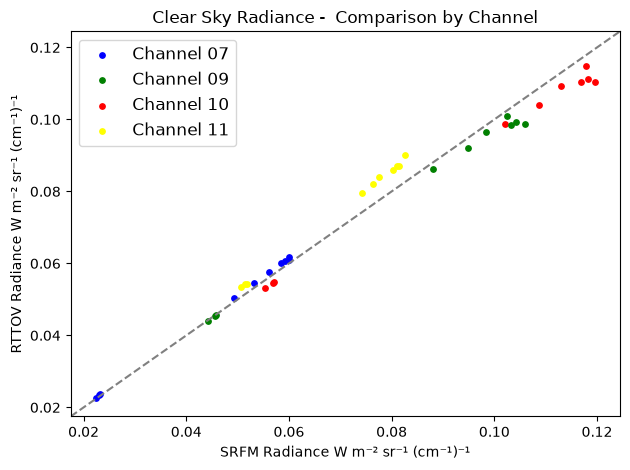

Statistics
----------------------------------------
Channel 07
  Mean Bias = -0.001106
  RMSE      = 0.001218
Channel 09
  Mean Bias = 0.002581
  RMSE      = 0.003412
Channel 10
  Mean Bias = 0.004392
  RMSE      = 0.004941
Channel 11
  Mean Bias = -0.005006
  RMSE      = 0.005263


In [16]:

fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "yellow"
}


all_diff = {ch: [] for ch in channels}
for profile in range(10):

    ClearSkyDatabtemp = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_btemp_WAV/ClearSkybtemp_Merge_{profile}_wav.csv"

    df = pd.read_csv(ClearSkyDatabtemp)

    for ch in channels:

        srfm = df[f"SRFM_Ch{ch:02d}"]
        rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3
        ax.scatter(
            srfm,
            rttov,
            color = colors[ch],
            s=15,
            label=f"Channel {ch:02d}" if profile == 0 else None,
            
        )
        if profile == 7 and ch == 7:
            print("Profile 7, Channel 7")
            print("SRFM:")
            print(srfm.values)
            print("RTTOV:")
            print(rttov.values)
         # Save differences for statistics
        all_diff[ch].extend((srfm - rttov).values)
#x=y
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, color="gray", linestyle="--")
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.set_xlabel("SRFM Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_ylabel("RTTOV Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_title("Clear Sky Radiance -  Comparison by Channel")
ax.legend(fontsize=12)



plt.tight_layout()
plt.show()

print("Statistics")
print("-" * 40)
for ch in channels:
    diff = np.array(all_diff[ch])
    mean_bias = diff.mean()
    rmse = np.sqrt(np.mean(diff**2))

    print(f"Channel {ch:02d}")
    print(f"  Mean Bias = {mean_bias:.6f}")
    print(f"  RMSE      = {rmse:.6f}")


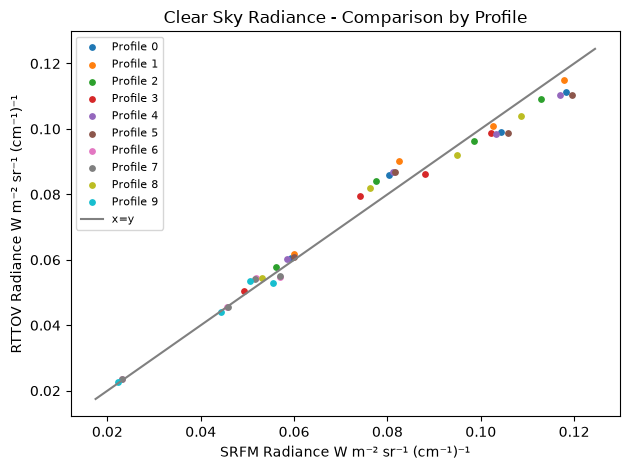

In [36]:
#Comparison by Profile
profile = 5
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]

# Color for each profile
profile_colors = plt.cm.tab10(range(10))  # 10 different colors for profiles 0-9

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_btemp_WAV/ClearSkybtemp_Merge_{profile}_wav.csv"

    df = pd.read_csv(ClearSkyData)

    for ch in channels:
        ax.scatter(
            df[f"SRFM_Ch{ch:02d}"],
            df[f"RTTOV_Ch{ch:02d}"] * 1e-3,
            color=profile_colors[profile],
            s=15,
            label=f"Profile {profile}" if ch == 7 else None
        )

# y=x line
lims = ax.get_xlim()
ax.plot(lims, lims, color="gray", label="x=y")
ax.set_xlabel("SRFM Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_ylabel("RTTOV Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_title("Clear Sky Radiance - Comparison by Profile")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Plot Fractional Difference -btemp

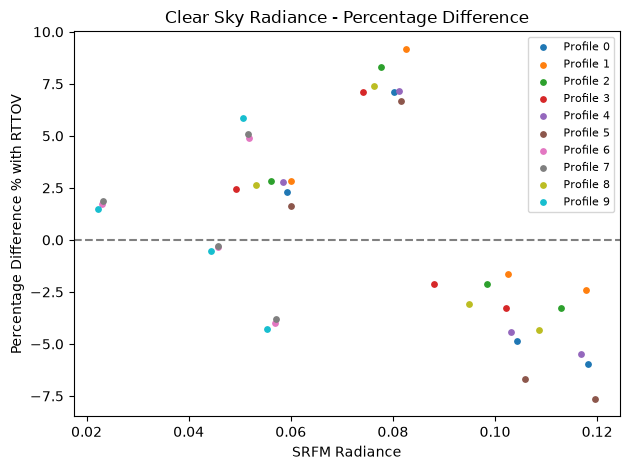

In [44]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "purple"
}

profile_colors = plt.cm.tab10(range(10))  # 10 different colors for profiles 0-9

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_btemp_WAV/ClearSkybtemp_Merge_{profile}_wav.csv"

    df = pd.read_csv(ClearSkyData)

    for ch in channels:
            srfm = df[f"SRFM_Ch{ch:02d}"]
            rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3
            fraction = ((rttov - srfm)/srfm) *100


            ax.scatter(srfm, fraction, color=profile_colors[profile],
            s=15,
            label=f"Profile {profile}" if ch == 7 else None
           )

ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("SRFM Radiance")
ax.set_ylabel("Percentage Difference % with RTTOV")
ax.set_title("Clear Sky Radiance - Percentage Difference")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

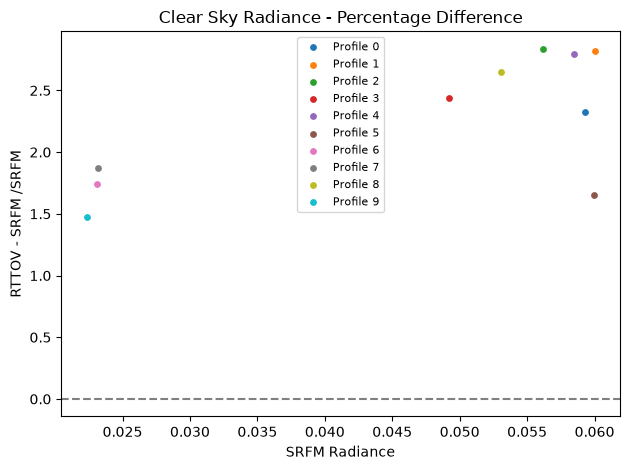

In [50]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "purple"
}
ch=7
profile_colors = plt.cm.tab10(range(10))  # 10 different colors for profiles 0-9

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_btemp_WAV/ClearSkybtemp_Merge_{profile}_wav.csv"

    df = pd.read_csv(ClearSkyData)

    
    srfm = df[f"SRFM_Ch{ch:02d}"]
    rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3
    fraction = ((rttov - srfm)/srfm) *100


    ax.scatter(srfm, fraction, color=profile_colors[profile],
    s=15,
    label=f"Profile {profile}" if ch == 7 else None
   )

ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("SRFM Radiance")
ax.set_ylabel("RTTOV - SRFM /SRFM")
ax.set_title("Clear Sky Radiance - Percentage Difference")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

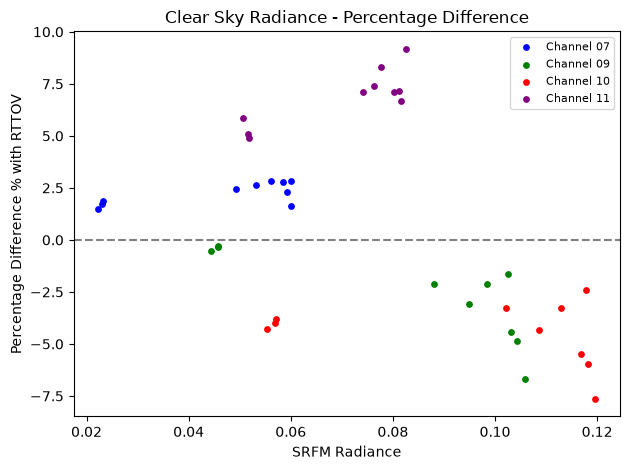

In [46]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "purple"
}

#profile_colors = plt.cm.tab10(range(10))  # 10 different colors for profiles 0-9

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_btemp_WAV/ClearSkybtemp_Merge_{profile}_wav.csv"

    df = pd.read_csv(ClearSkyData)

    for ch in channels:
            srfm = df[f"SRFM_Ch{ch:02d}"]
            rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3
            fraction = ((rttov - srfm)/srfm) *100


            ax.scatter(srfm, fraction, color=colors[ch],
            s=15,
            label=f"Channel {ch:02d}" if profile == 0 else None
           )

ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("SRFM Radiance")
ax.set_ylabel("Percentage Difference % with RTTOV")
ax.set_title("Clear Sky Radiance - Percentage Difference")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

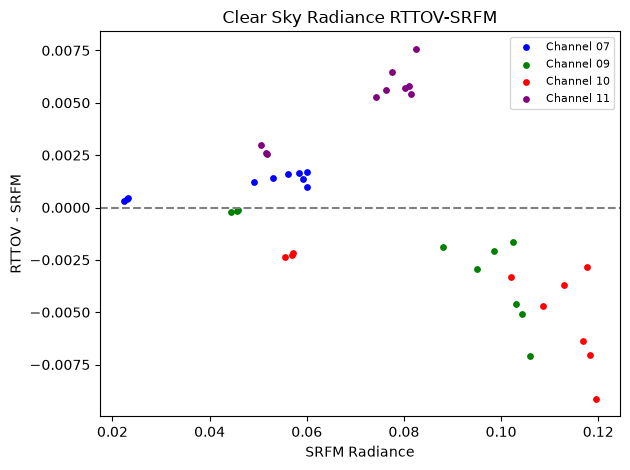

In [48]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "purple"
}

#profile_colors = plt.cm.tab10(range(10))  # 10 different colors for profiles 0-9

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge_btemp_WAV/ClearSkybtemp_Merge_{profile}_wav.csv"

    df = pd.read_csv(ClearSkyData)

    for ch in channels:
            srfm = df[f"SRFM_Ch{ch:02d}"]
            rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3
            differ = rttov - srfm


            ax.scatter(srfm, differ, color=colors[ch],
            s=15,
            label=f"Channel {ch:02d}" if profile == 0 else None
           )

ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("SRFM Radiance")
ax.set_ylabel("RTTOV - SRFM")
ax.set_title("Clear Sky Radiance RTTOV-SRFM")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Old data

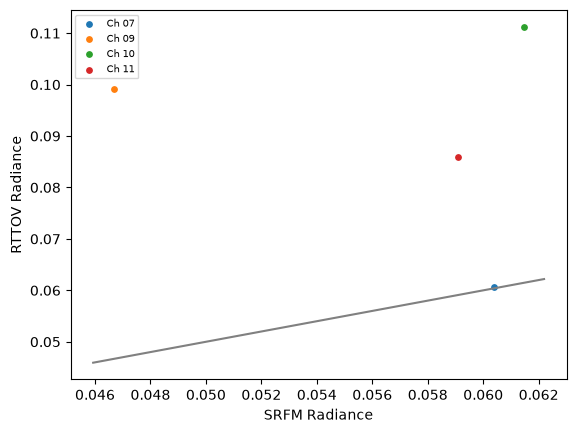

In [103]:
profile = 0
ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge/ClearSky_Merge_{profile}.csv"


df = pd.read_csv(ClearSkyData)

# Extract specific columns
clear_s = ["SRFM_Ch07", "SRFM_Ch09","SRFM_Ch10","SRFM_Ch11"] 
clear_r = ["RTTOV_Ch07", "RTTOV_Ch09","RTTOV_Ch10","RTTOV_Ch11"] 
res_s = df[clear_s]
res_r = df[clear_r]
res_W=res_r*10**-3


clear_s = ["SRFM_Ch07", "SRFM_Ch09","SRFM_Ch10","SRFM_Ch11"] 
clear_r = ["RTTOV_Ch07", "RTTOV_Ch09","RTTOV_Ch10","RTTOV_Ch11"] 
res_s = df[clear_s]
res_r = df[clear_r]
res_W=res_r*10**-3


fig, ax = plt.subplots()
channels = [7, 9, 10, 11]

for ch in channels:
    ax.scatter(
        df[f"SRFM_Ch{ch:02d}"],
        df[f"RTTOV_Ch{ch:02d}"] * 1e-3,
        label=f"Ch {ch:02d}",
        s = 15
    )
lims = ax.get_xlim()
ax.plot(lims, lims, color = "gray")
ax.set_xlabel("SRFM Radiance")
ax.set_ylabel("RTTOV Radiance")
ax.legend(fontsize = 7)




Statistics
----------------------------------------
Channel 07
  Mean Bias = 0.001603
  RMSE      = 0.002113
Channel 09
  Mean Bias = -0.037386
  RMSE      = 0.042788
Channel 10
  Mean Bias = -0.030254
  RMSE      = 0.040061
Channel 11
  Mean Bias = -0.016927
  RMSE      = 0.022554


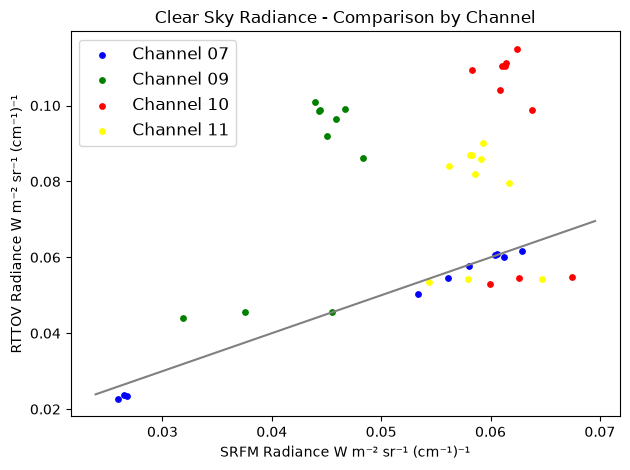

In [170]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "yellow"
}

# Store differences for each channel
differences = {ch: [] for ch in channels}

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge/ClearSky_Merge_{profile}.csv"
    df = pd.read_csv(ClearSkyData)

    for ch in channels:
        srfm = df[f"SRFM_Ch{ch:02d}"]
        rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3

        ax.scatter(
            srfm,
            rttov,
            color=colors[ch],
            s=15,
            label=f"Channel {ch:02d}" if profile == 0 else None,
        )

        differences[ch].extend((srfm - rttov).to_numpy())

lims = ax.get_xlim()
ax.plot(lims, lims, color="gray")

ax.set_xlabel("SRFM Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_ylabel("RTTOV Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_title("Clear Sky Radiance - Comparison by Channel")
ax.legend(fontsize=12)

print("Statistics")
print("-" * 40)
for ch in channels:
    diff = np.array(differences[ch])
    mean_bias = np.mean(diff)
    rmse = np.sqrt(np.mean(diff**2))

    print(f"Channel {ch:02d}")
    print(f"  Mean Bias = {mean_bias:.6f}")
    print(f"  RMSE      = {rmse:.6f}")

plt.tight_layout()
plt.show()

In [104]:
comp = pd.concat([res_s, res_W], axis=1)
print(comp)

   SRFM_Ch07  SRFM_Ch09  SRFM_Ch10  SRFM_Ch11  RTTOV_Ch07  RTTOV_Ch09  \
0   0.060385   0.046673   0.061455   0.059094    0.060666    0.099189   

   RTTOV_Ch10  RTTOV_Ch11  
0    0.111255    0.086006  


Mean bias: 0.0008409499999999931
RMSE: 0.0008409499999999931


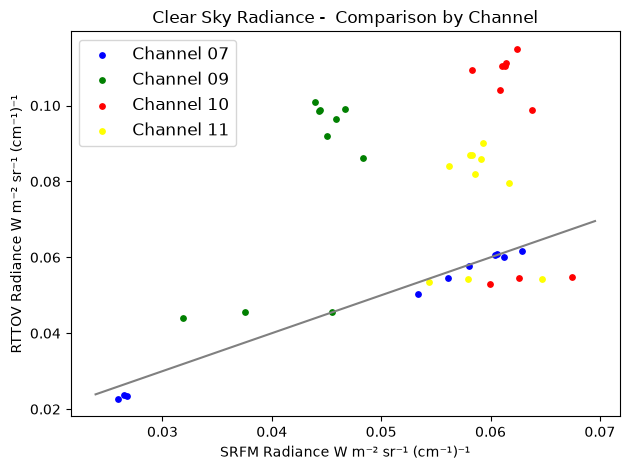

In [169]:

fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "yellow"
}

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge/ClearSky_Merge_{profile}.csv"

    df = pd.read_csv(ClearSkyData)

    for ch in channels:
        ax.scatter(
            df[f"SRFM_Ch{ch:02d}"],
            df[f"RTTOV_Ch{ch:02d}"] * 1e-3,
            color = colors[ch],
            s=15,
            label=f"Channel {ch:02d}" if profile == 0 else None,
            
        )

# y=x line
lims = ax.get_xlim()
ax.plot(lims, lims, color="gray")

ax.set_xlabel("SRFM Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_ylabel("RTTOV Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_title("Clear Sky Radiance -  Comparison by Channel")
ax.legend(fontsize=12)

difference = df[f"SRFM_Ch{ch:02d}"] - df[f"RTTOV_Ch{ch:02d}"] * 1e-3


plt.tight_layout()
plt.show()

Statistics
----------------------------------------
Channel 07
  Mean Bias = 0.001603
  RMSE      = 0.002113
Channel 09
  Mean Bias = -0.037386
  RMSE      = 0.042788
Channel 10
  Mean Bias = -0.030254
  RMSE      = 0.040061
Channel 11
  Mean Bias = -0.016927
  RMSE      = 0.022554


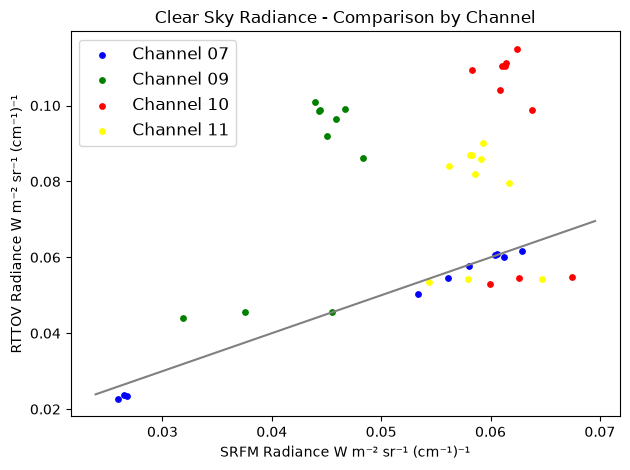

In [170]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "yellow"
}

# Store differences for each channel
differences = {ch: [] for ch in channels}

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge/ClearSky_Merge_{profile}.csv"
    df = pd.read_csv(ClearSkyData)

    for ch in channels:
        srfm = df[f"SRFM_Ch{ch:02d}"]
        rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3

        ax.scatter(
            srfm,
            rttov,
            color=colors[ch],
            s=15,
            label=f"Channel {ch:02d}" if profile == 0 else None,
        )

        differences[ch].extend((srfm - rttov).to_numpy())

lims = ax.get_xlim()
ax.plot(lims, lims, color="gray")

ax.set_xlabel("SRFM Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_ylabel("RTTOV Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_title("Clear Sky Radiance - Comparison by Channel")
ax.legend(fontsize=12)

print("Statistics")
print("-" * 40)
for ch in channels:
    diff = np.array(differences[ch])
    mean_bias = np.mean(diff)
    rmse = np.sqrt(np.mean(diff**2))

    print(f"Channel {ch:02d}")
    print(f"  Mean Bias = {mean_bias:.6f}")
    print(f"  RMSE      = {rmse:.6f}")

plt.tight_layout()
plt.show()

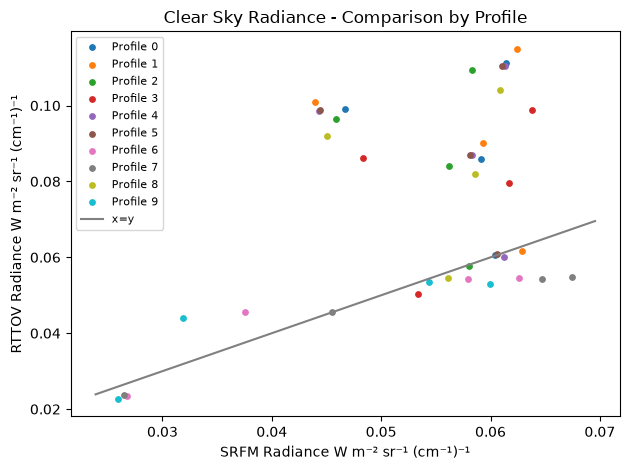

In [168]:
#Comparison by Profile

fig, ax = plt.subplots()

channels = [7, 9, 10, 11]

# Color for each profile
profile_colors = plt.cm.tab10(range(10))  # 10 different colors for profiles 0-9

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge/ClearSky_Merge_{profile}.csv"

    df = pd.read_csv(ClearSkyData)

    for ch in channels:
        ax.scatter(
            df[f"SRFM_Ch{ch:02d}"],
            df[f"RTTOV_Ch{ch:02d}"] * 1e-3,
            color=profile_colors[profile],
            s=15,
            label=f"Profile {profile}" if ch == 7 else None
        )

# y=x line
lims = ax.get_xlim()
ax.plot(lims, lims, color="gray", label="x=y")
ax.set_xlabel("SRFM Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_ylabel("RTTOV Radiance W m⁻² sr⁻¹ (cm⁻¹)⁻¹")
ax.set_title("Clear Sky Radiance - Comparison by Profile")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

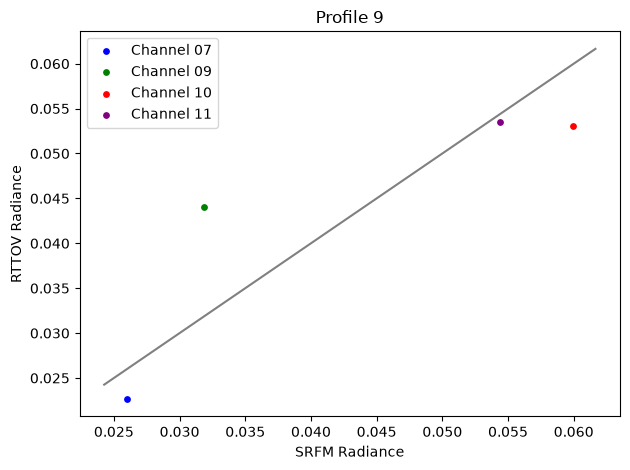

In [127]:
#Individual Profile
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "purple"
}

profile = "9"
ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge/ClearSky_Merge_{profile}.csv"

df = pd.read_csv(ClearSkyData)

for ch in channels:
    ax.scatter(
        df[f"SRFM_Ch{ch:02d}"],
        df[f"RTTOV_Ch{ch:02d}"] * 1e-3,
        color = colors[ch],
        label=f"Channel {ch:02d}",
        s=15
    )

# y=x line
lims = ax.get_xlim()
ax.plot(lims, lims, color="gray")

ax.set_xlabel("SRFM Radiance")
ax.set_ylabel("RTTOV Radiance")
ax.set_title("Profile 9")

plt.legend()
plt.tight_layout()
plt.show()

## Plot Fractional Difference - old data

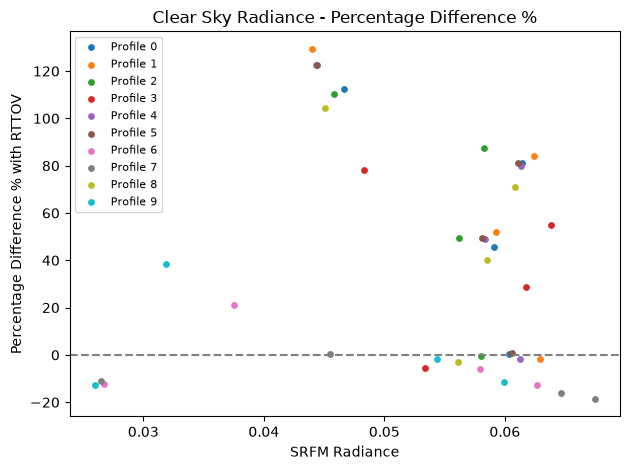

In [140]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "purple"
}

profile_colors = plt.cm.tab10(range(10))  # 10 different colors for profiles 0-9

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge/ClearSky_Merge_{profile}.csv"

    df = pd.read_csv(ClearSkyData)

    for ch in channels:
            srfm = df[f"SRFM_Ch{ch:02d}"]
            rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3
            fraction = ((rttov - srfm)/srfm) *100


            ax.scatter(srfm, fraction, color=profile_colors[profile],
            s=15,
            label=f"Channel {ch:02d}" if profile == 0 else None
           )

ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("SRFM Radiance")
ax.set_ylabel("Percentage Difference % with RTTOV")
ax.set_title("Clear Sky Radiance - Percentage Difference %")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

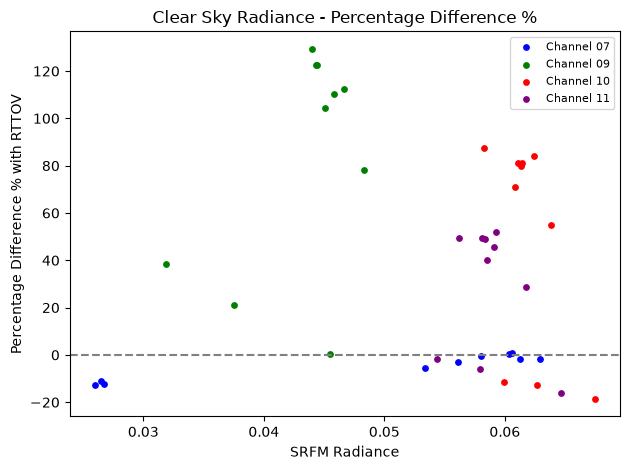

In [144]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "purple"
}

profile_colors = plt.cm.tab10(range(10))  # 10 different colors for profiles 0-9

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge/ClearSky_Merge_{profile}.csv"

    df = pd.read_csv(ClearSkyData)

    for ch in channels:
            srfm = df[f"SRFM_Ch{ch:02d}"]
            rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3
            fraction = ((rttov - srfm)/srfm) *100


            ax.scatter(srfm, fraction, 
            s=15,
            color = colors[ch],
            label=f"Channel {ch:02d}" if profile == 0 else None)

ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("SRFM Radiance")
ax.set_ylabel("Percentage Difference % with RTTOV")
ax.set_title("Clear Sky Radiance - Percentage Difference %")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Plot Fractional Difference -old

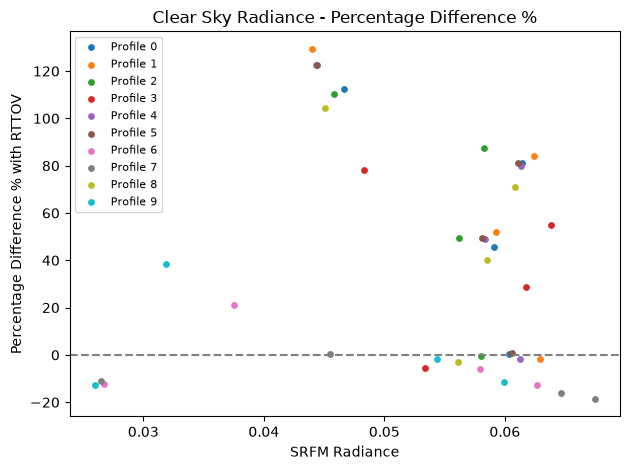

In [140]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "purple"
}

profile_colors = plt.cm.tab10(range(10))  # 10 different colors for profiles 0-9

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge/ClearSky_Merge_{profile}.csv"

    df = pd.read_csv(ClearSkyData)

    for ch in channels:
            srfm = df[f"SRFM_Ch{ch:02d}"]
            rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3
            fraction = ((rttov - srfm)/srfm) *100


            ax.scatter(srfm, fraction, color=profile_colors[profile],
            s=15,
            label=f"Channel {ch:02d}" if profile == 0 else None
           )

ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("SRFM Radiance")
ax.set_ylabel("Percentage Difference % with RTTOV")
ax.set_title("Clear Sky Radiance - Percentage Difference %")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

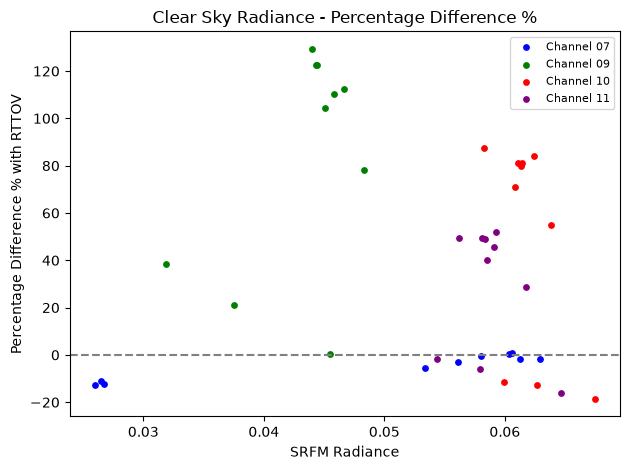

In [144]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
colors = {
    7: "blue",
    9: "green",
    10: "red",
    11: "purple"
}

profile_colors = plt.cm.tab10(range(10))  # 10 different colors for profiles 0-9

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge/ClearSky_Merge_{profile}.csv"

    df = pd.read_csv(ClearSkyData)

    for ch in channels:
            srfm = df[f"SRFM_Ch{ch:02d}"]
            rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3
            fraction = ((rttov - srfm)/srfm) *100


            ax.scatter(srfm, fraction, 
            s=15,
            color = colors[ch],
            label=f"Channel {ch:02d}" if profile == 0 else None)

ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("SRFM Radiance")
ax.set_ylabel("Percentage Difference % with RTTOV")
ax.set_title("Clear Sky Radiance - Percentage Difference %")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


## Plot Fractional Difference Histogram

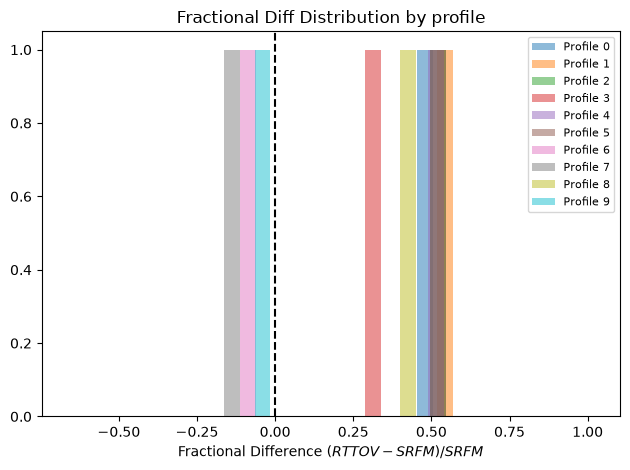

In [146]:
fig, ax = plt.subplots()

channels = [7, 9, 10, 11]
profile_colors = plt.cm.tab10(range(10))

for profile in range(10):

    ClearSkyData = f"/home/m/moulin-garrigues/RTTOV/Full_Rad_3_08/Merge/ClearSky_Merge_{profile}.csv"
    df = pd.read_csv(ClearSkyData)


    for ch in channels:
        srfm = df[f"SRFM_Ch{ch:02d}"]
        rttov = df[f"RTTOV_Ch{ch:02d}"] * 1e-3

        fraction = (rttov - srfm) / srfm

    ax.hist(
        fraction,
        bins=20,
        alpha=0.5,
        color=profile_colors[profile],
        label=f"Profile {profile}"
    )

ax.axvline(0, color="black", linestyle="--")

ax.set_xlabel("Fractional Difference $(RTTOV-SRFM)/SRFM$")
ax.set_title("Fractional Diff Distribution by profile")

ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Checking Clear Sky SRFM Profiles

In [161]:

atm_file = "/network/group/aopp/eodg/RGG008_GRAINGER_IASIVOLC/knizek/MetOffice_clear_sky/srfm_atm_profiles/5.atm"

def extract_block(lines, name):
    values = []
    reading = False

    for line in lines:
        line = line.strip()

        if line.startswith(name):
            reading = True
            continue

        if reading:
            if line.startswith("*"):
                break
            values.extend(line.split())

    return np.array(values, dtype=float)

with open(atm_file) as f:
    lines = f.readlines()

pressure = extract_block(lines, "*PRE")
temperature = extract_block(lines, "*TEM")
humidity = extract_block(lines, "*H2O (ppmv)")

df = pd.DataFrame({
    "Pressure_hPa": pressure,
    "Temperature_K": temperature,
    "H2O_ppmv": humidity
})

df.to_csv("/home/m/moulin-garrigues/SRFM_RTTOV/Mes_resultats/SRFM_profiles/Clear_prof/5_pressure_temperature_humidityCLEAR.csv", index=False)

print("CSV written to pressure_temperature_humidity.csv")

print(df)

CSV written to pressure_temperature_humidity.csv
     Pressure_hPa  Temperature_K    H2O_ppmv
0     1012.200000         299.30  28142.0000
1     1009.600000         299.07  28046.0000
2     1006.900000         298.82  28006.0000
3     1003.900000         298.56  27979.0000
4     1000.600000         298.28  27958.0000
..            ...            ...         ...
132      0.082875         222.23      5.6002
133      0.057470         212.00      5.0672
134      0.038842         202.33      4.6205
135      0.025513         194.93      3.6617
136      0.010002         185.93      2.3182

[137 rows x 3 columns]
